# Home Depot (HD): Time-Series Stylised Facts, CAPM/APT, ARMA & GARCH

**Author:** Yurui Qiu · Personal project

This notebook:
1. Pulls HD daily/hourly prices and computes log-returns
2. Examines stylised facts (volatility clustering, fat tails, non-normality)
3. Verifies data sources against the Fama-French library
4. Estimates CAPM and a Fama-French five-factor + momentum + oil APT model
5. Fits an ARMA model for the conditional mean and evaluates it out-of-sample
6. Formally tests for ARCH effects and fits a GARCH(1,1) model for the
   conditional variance, then compares ARMA-only vs ARMA+GARCH interval forecasts


## 0. Setup

In [3]:
import io, zipfile, itertools
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import bds
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error
import yfinance as yf

sns.set_theme(style="whitegrid")
TICKER = "HD"
MARKET_TICKER = "^GSPC"
TBILL_TICKER = "^IRX"
OIL_TICKER = "CL=F"
TRADING_DAYS = 252

import os
os.makedirs("assets", exist_ok=True)  # works whether run standalone (Colab) or inside the repo


In [4]:
!pip install arch -q

## 1. Load price data and compute log-returns

In [5]:
def load_prices(ticker, period, interval):
    df = yf.download(ticker, period=period, interval=interval, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

daily = load_prices(TICKER, period="2y", interval="1d")
hourly = load_prices(TICKER, period="60d", interval="1h")

daily["log_return"] = np.log(daily["Close"] / daily["Close"].shift(1))
hourly["log_return"] = np.log(hourly["Close"] / hourly["Close"].shift(1))

daily_lr = daily["log_return"].dropna()
hourly_lr = hourly["log_return"].dropna()
daily_lr.tail(), hourly_lr.tail()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(Date
 2026-06-29    0.005574
 2026-06-30    0.005316
 2026-07-01   -0.005231
 2026-07-02    0.019923
 2026-07-06   -0.020465
 Name: log_return, dtype: float64,
 Datetime
 2026-07-06 15:30:00+00:00    0.004581
 2026-07-06 16:30:00+00:00    0.003223
 2026-07-06 17:30:00+00:00    0.001536
 2026-07-06 18:30:00+00:00   -0.003047
 2026-07-06 19:30:00+00:00    0.000086
 Name: log_return, dtype: float64)

## 2. Stylised facts

### 2a. Return series plots

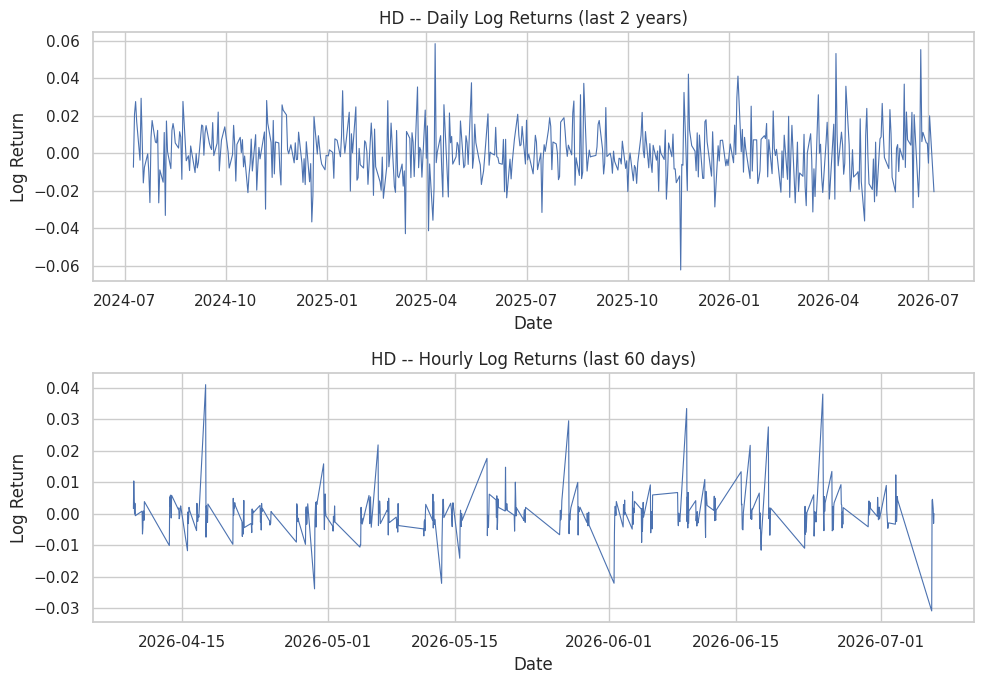

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))
axes[0].plot(daily_lr.index, daily_lr.values, linewidth=0.8)
axes[0].set_title(f"{TICKER} -- Daily Log Returns (last 2 years)")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Log Return")

axes[1].plot(hourly_lr.index, hourly_lr.values, linewidth=0.8)
axes[1].set_title(f"{TICKER} -- Hourly Log Returns (last 60 days)")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Log Return")
plt.tight_layout(); plt.savefig("assets/fig1_returns.png", dpi=150); plt.show()


### 2b. Distributional properties

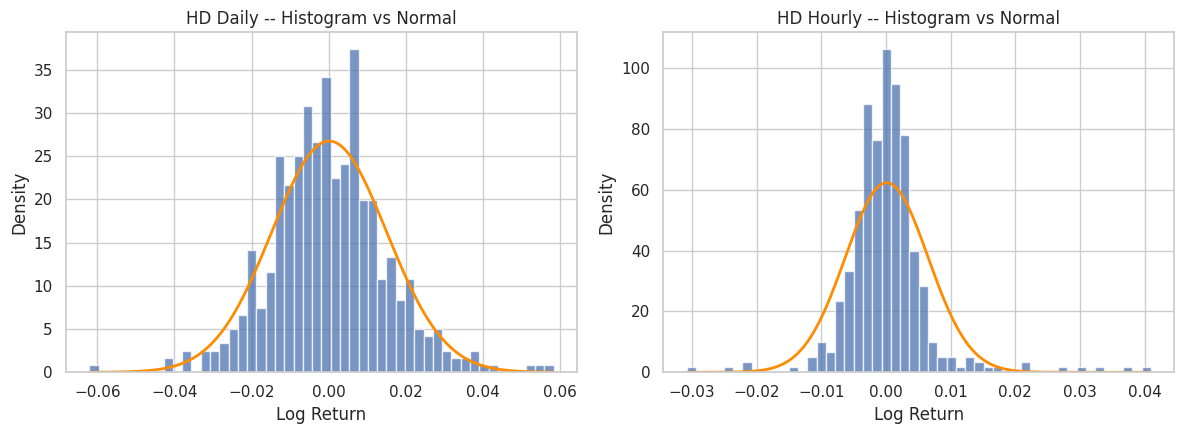

,Daily,Hourly
Mean,0.000150,0.000125
Std Dev,0.014921,0.006406
Skewness,0.215516,1.523762
Excess Kurtosis,1.323693,11.701335


In [7]:
def hist_with_normal_fit(returns, title, ax):
    mu, sigma = returns.mean(), returns.std(ddof=1)
    ax.hist(returns.values, bins=50, density=True, alpha=0.75)
    x = np.linspace(returns.min(), returns.max(), 400)
    ax.plot(x, norm.pdf(x, loc=mu, scale=sigma), linewidth=2.0, color="darkorange")
    ax.set_title(title); ax.set_xlabel("Log Return"); ax.set_ylabel("Density")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
hist_with_normal_fit(daily_lr, f"{TICKER} Daily -- Histogram vs Normal", axes[0])
hist_with_normal_fit(hourly_lr, f"{TICKER} Hourly -- Histogram vs Normal", axes[1])
plt.tight_layout(); plt.savefig("assets/fig2_histograms.png", dpi=150); plt.show()

def describe_returns(s):
    return pd.Series({
        "Mean": s.mean(),
        "Std Dev": s.std(ddof=1),
        "Skewness": s.skew(),
        "Excess Kurtosis": s.kurtosis(),
    })

stats_table = pd.DataFrame({"Daily": describe_returns(daily_lr), "Hourly": describe_returns(hourly_lr)})
stats_table


## 3. Data matching and verification

Assembles HD returns, S&P 500 returns, the 13-week T-bill rate (`^IRX`), and the
Fama-French five factors + momentum, and checks the sources are consistent with
each other before using them downstream.

In [8]:
def load_max_history(ticker):
    df = yf.download(ticker, period="max", interval="1d", auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

hd_hist = load_max_history(TICKER)
mkt_hist = load_max_history(MARKET_TICKER)
tbill_hist = load_max_history(TBILL_TICKER)

hd_hist["ret"] = hd_hist["Close"].pct_change()
mkt_hist["ret"] = mkt_hist["Close"].pct_change()
tbill_hist["rf_annual"] = tbill_hist["Close"] / 100.0

panel = pd.concat([
    hd_hist["ret"].rename("HD_ret"),
    mkt_hist["ret"].rename("MKT_ret"),
    tbill_hist["rf_annual"].rename("Tbill_annual"),
], axis=1).dropna()
panel.head()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,HD_ret,MKT_ret,Tbill_annual
Date,,,
1981-09-23,0.0,-0.008828,0.1420
1981-09-24,0.0,-0.005534,0.1421
1981-09-25,0.0,-0.019477,0.1430
1981-09-28,0.0,0.024475,0.1412
1981-09-29,0.0,0.003549,0.1416


In [9]:
def load_french_factors():
    ff5_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip"
    mom_url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Momentum_Factor_daily_CSV.zip"

    def _read_zip_csv(url, skiprows):
        r = requests.get(url)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        name = [n for n in z.namelist() if n.lower().endswith(".csv")][0]
        return pd.read_csv(z.open(name), skiprows=skiprows)

    ff5 = _read_zip_csv(ff5_url, skiprows=3).rename(columns={"Unnamed: 0": "Date"})
    ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m%d", errors="coerce")
    ff5 = ff5.dropna(subset=["Date"]).set_index("Date").astype(float) / 100.0

    mom = _read_zip_csv(mom_url, skiprows=13).rename(columns={"Unnamed: 0": "Date"})
    mom["Date"] = pd.to_datetime(mom["Date"], format="%Y%m%d", errors="coerce")
    mom = mom.dropna(subset=["Date"]).set_index("Date")
    mom_col = [c for c in mom.columns if c.strip().lower().startswith("mom")][0]
    mom = mom[[mom_col]].astype(float) / 100.0
    mom.columns = ["MOM"]

    return ff5.join(mom, how="left")

ff = load_french_factors()
panel = panel.join(ff, how="inner")
print("Merged panel:", panel.shape, panel.index.min(), "-->", panel.index.max())
panel.head()


Merged panel: (11201, 10) 1981-09-23 00:00:00 --> 2026-05-29 00:00:00


,HD_ret,MKT_ret,Tbill_annual,Mkt-RF,SMB,HML,RMW,CMA,RF,MOM
Date,,,,,,,,,,
1981-09-23,0.0,-0.008828,0.1420,-0.0122,-0.0093,0.0091,0.0009,0.0038,0.0006,0.0048
1981-09-24,0.0,-0.005534,0.1421,-0.0039,0.0032,0.0018,-0.0002,-0.0006,0.0006,0.0038
1981-09-25,0.0,-0.019477,0.1430,-0.0240,-0.0111,0.0175,-0.0023,0.0074,0.0006,0.0058
1981-09-28,0.0,0.024475,0.1412,0.0194,-0.0182,-0.0159,0.0108,-0.0124,0.0006,-0.0022
1981-09-29,0.0,0.003549,0.1416,0.0085,0.0152,-0.0126,-0.0001,-0.0038,0.0006,0.0012


### 3a. S&P 500 excess return vs Fama-French market excess return

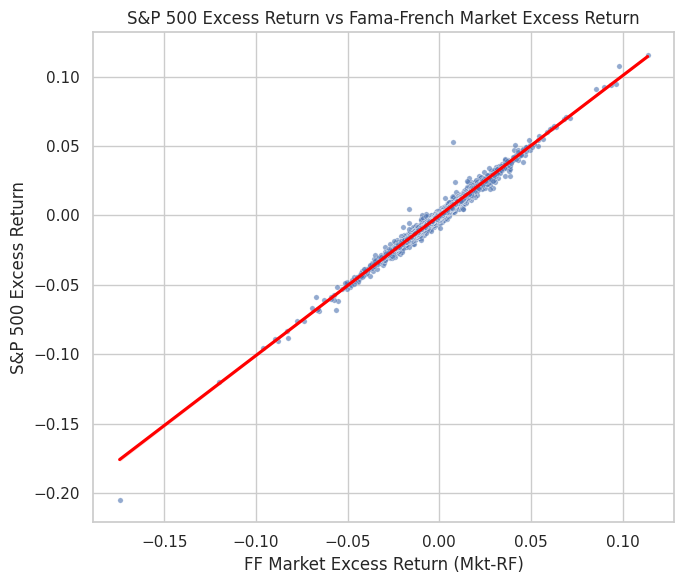

In [10]:
panel["SP500_excess"] = panel["MKT_ret"] - panel["RF"]

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=panel["Mkt-RF"], y=panel["SP500_excess"], s=15, alpha=0.6, ax=ax)
sns.regplot(x=panel["Mkt-RF"], y=panel["SP500_excess"], scatter=False, color="red", ax=ax)
ax.set(title="S&P 500 Excess Return vs Fama-French Market Excess Return",
       xlabel="FF Market Excess Return (Mkt-RF)", ylabel="S&P 500 Excess Return")
plt.tight_layout(); plt.savefig("assets/fig3_sp500_vs_ff.png", dpi=150); plt.show()


### 3b. T-bill rate vs Fama-French risk-free rate

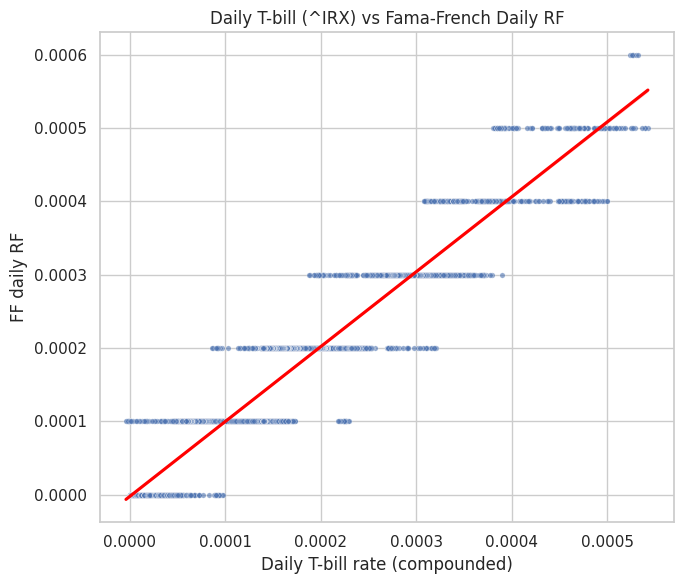

In [11]:
panel["Tbill_daily"] = (1.0 + panel["Tbill_annual"]) ** (1.0 / TRADING_DAYS) - 1.0

fig, ax = plt.subplots(figsize=(7, 6))
tmp = panel[["Tbill_daily", "RF"]].dropna()
sns.scatterplot(x=tmp["Tbill_daily"], y=tmp["RF"], s=15, alpha=0.6, ax=ax)
sns.regplot(x=tmp["Tbill_daily"], y=tmp["RF"], scatter=False, color="red", ax=ax)
ax.set(title="Daily T-bill (^IRX) vs Fama-French Daily RF",
       xlabel="Daily T-bill rate (compounded)", ylabel="FF daily RF")
plt.tight_layout(); plt.savefig("assets/fig4_tbill_vs_ff.png", dpi=150); plt.show()


## 4. CAPM

In [12]:
capm_df = panel.dropna(subset=["HD_ret", "Mkt-RF", "RF"]).copy()
capm_df["HD_excess"] = capm_df["HD_ret"] - capm_df["RF"]

X = sm.add_constant(capm_df["Mkt-RF"])
y = capm_df["HD_excess"]
capm_model = sm.OLS(y, X).fit()
print(capm_model.summary())

beta_capm = capm_model.params["Mkt-RF"]
alpha_capm = capm_model.params["const"]
print(f"beta = {beta_capm:.3f}, alpha = {alpha_capm:.5f}")


                            OLS Regression Results                            
Dep. Variable:              HD_excess   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     4451.
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:31:11   Log-Likelihood:                 28392.
No. Observations:               11201   AIC:                        -5.678e+04
Df Residuals:                   11199   BIC:                        -5.677e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      3.092      0.0

In [13]:
# Replication portfolio: RF + beta * (Mkt - RF), compared with HD directly
capm_df["rep_portfolio"] = capm_df["RF"] + beta_capm * capm_df["Mkt-RF"]

def perf_stats(returns, rf):
    mean_r, var_r = returns.mean(), returns.var()
    sharpe = (mean_r - rf.mean()) / returns.std()
    return mean_r, var_r, sharpe

perf_table = pd.DataFrame({
    "Replication Portfolio": perf_stats(capm_df["rep_portfolio"], capm_df["RF"]),
    "Home Depot (HD)": perf_stats(capm_df["HD_ret"], capm_df["RF"]),
}, index=["Mean E[R]", "Variance", "Sharpe Ratio"])
perf_table


,Replication Portfolio,Home Depot (HD)
Mean E[R],0.000543,0.001104
Variance,0.000146,0.000514
Sharpe Ratio,0.033145,0.042397


## 5. Arbitrage Pricing Theory (Fama-French five-factor + momentum + oil)

In [14]:
apt_df = panel.dropna(subset=["HD_ret", "RF", "Mkt-RF", "SMB", "HML", "RMW", "CMA"]).copy()
apt_df["HD_excess"] = apt_df["HD_ret"] - apt_df["RF"]

X5 = sm.add_constant(apt_df[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]])
ff5_model = sm.OLS(apt_df["HD_excess"], X5).fit()
print(ff5_model.summary())


                            OLS Regression Results                            
Dep. Variable:              HD_excess   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     933.6
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:31:11   Log-Likelihood:                 28470.
No. Observations:               11201   AIC:                        -5.693e+04
Df Residuals:                   11195   BIC:                        -5.688e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      2.583      0.0

In [15]:
apt_mom_df = panel.dropna(subset=["HD_ret", "RF", "Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]).copy()
apt_mom_df["HD_excess"] = apt_mom_df["HD_ret"] - apt_mom_df["RF"]

X6 = sm.add_constant(apt_mom_df[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM"]])
ff6_model = sm.OLS(apt_mom_df["HD_excess"], X6).fit()
print(f"FF5 adj. R^2 = {ff5_model.rsquared_adj:.3f} | FF5+MOM adj. R^2 = {ff6_model.rsquared_adj:.3f}")
print(ff6_model.summary())


FF5 adj. R^2 = 0.294 | FF5+MOM adj. R^2 = 0.294
                            OLS Regression Results                            
Dep. Variable:              HD_excess   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     778.9
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:31:11   Log-Likelihood:                 28472.
No. Observations:               11201   AIC:                        -5.693e+04
Df Residuals:                   11194   BIC:                        -5.688e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

In [16]:
oil = load_max_history(OIL_TICKER)[["Close"]].rename(columns={"Close": "Oil_close"})
oil["Oil_ret"] = oil["Oil_close"].pct_change()

apt_oil_df = apt_mom_df.join(oil["Oil_ret"], how="inner").dropna(subset=["Oil_ret"])
X7 = sm.add_constant(apt_oil_df[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "MOM", "Oil_ret"]])
ff7_model = sm.OLS(apt_oil_df["HD_excess"], X7).fit()

print(f"FF5+MOM adj. R^2 = {ff6_model.rsquared_adj:.3f} | +Oil adj. R^2 = {ff7_model.rsquared_adj:.3f}")
print(ff7_model.summary())


[*********************100%***********************]  1 of 1 completed


FF5+MOM adj. R^2 = 0.294 | +Oil adj. R^2 = 0.456
                            OLS Regression Results                            
Dep. Variable:              HD_excess   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.456
Method:                 Least Squares   F-statistic:                     774.2
Date:                Tue, 07 Jul 2026   Prob (F-statistic):               0.00
Time:                        08:31:12   Log-Likelihood:                 18633.
No. Observations:                6458   AIC:                        -3.725e+04
Df Residuals:                    6450   BIC:                        -3.720e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
con

In [17]:
# Multicollinearity check
X_vif = X7.drop(columns="const")
vif_table = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_table


,Variable,VIF
0,Mkt-RF,1.284974
1,SMB,1.142253
2,HML,1.629618
3,RMW,1.279924
4,CMA,1.522584
5,MOM,1.284449
6,Oil_ret,1.027218


## 6. ARMA model for the conditional mean

### 6a. ACF / PACF of returns and squared returns

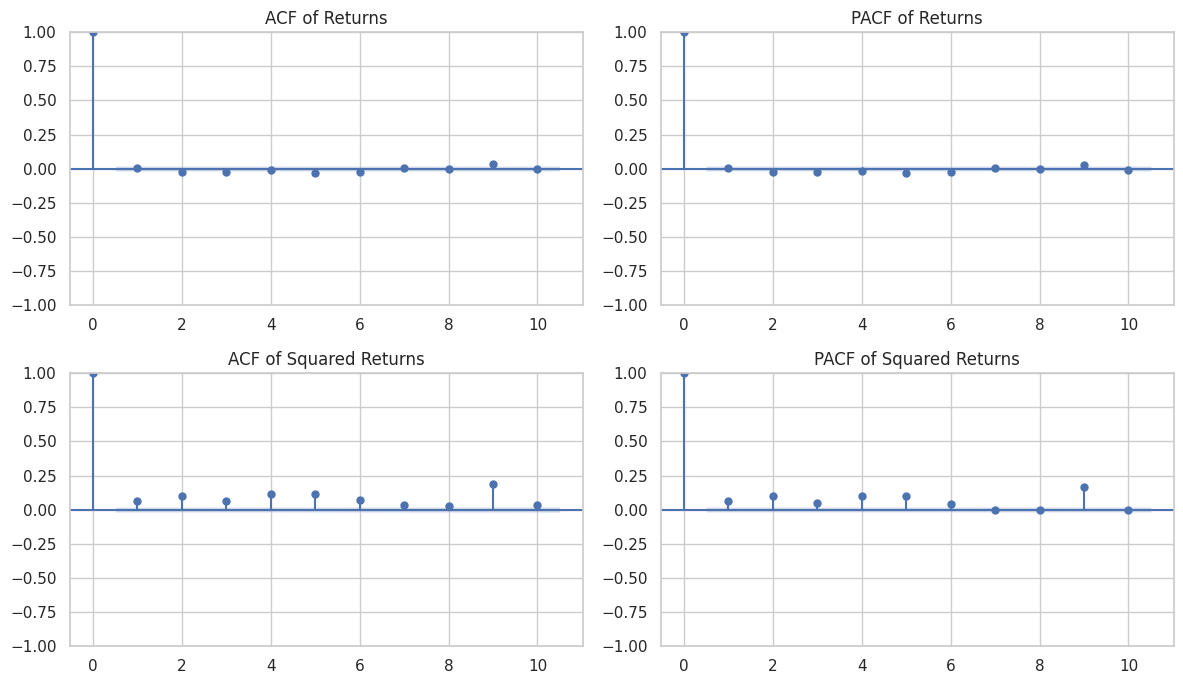

In [18]:
returns = apt_mom_df["HD_ret"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(returns, lags=10, ax=axes[0, 0]); axes[0, 0].set_title("ACF of Returns")
plot_pacf(returns, lags=10, ax=axes[0, 1]); axes[0, 1].set_title("PACF of Returns")
plot_acf(returns**2, lags=10, ax=axes[1, 0]); axes[1, 0].set_title("ACF of Squared Returns")
plot_pacf(returns**2, lags=10, ax=axes[1, 1]); axes[1, 1].set_title("PACF of Squared Returns")
plt.tight_layout(); plt.savefig("assets/fig5_acf_pacf.png", dpi=150); plt.show()


### 6b. Grid search over low-order ARMA(p,q) specifications

In [19]:
def search_arma_orders(series, max_order=2):
    results = []
    for p, q in itertools.product(range(max_order + 1), repeat=2):
        try:
            fit = ARIMA(series, order=(p, 0, q), trend="c",
                        enforce_stationarity=False, enforce_invertibility=False).fit()
            results.append({"order": (p, q), "aic": fit.aic, "bic": fit.bic, "model": fit})
        except Exception:
            continue
    return pd.DataFrame(results).sort_values("aic")

arma_grid = search_arma_orders(returns)
arma_grid[["order", "aic", "bic"]]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,order,aic,bic
7,"(2, 1)",-53041.012919,-53004.395020
5,"(1, 2)",-53035.646339,-52999.028886
4,"(1, 1)",-53028.143334,-52998.849015
8,"(2, 2)",-53025.848419,-52981.907476
0,"(0, 0)",-53024.074460,-53009.427122
3,"(1, 0)",-53022.412830,-53000.441823
6,"(2, 0)",-53021.671247,-52992.376928
1,"(0, 1)",-53016.691596,-52994.720856
2,"(0, 2)",-53015.989657,-52986.695695


In [20]:
best_row = arma_grid.iloc[0]
best_order = best_row["order"]
best_model = best_row["model"]
print(f"Selected ARMA{best_order} by AIC")
print(best_model.summary())


Selected ARMA(2, 1) by AIC
                               SARIMAX Results                                
Dep. Variable:                 HD_ret   No. Observations:                11201
Model:                 ARIMA(2, 0, 1)   Log Likelihood               26525.506
Date:                Tue, 07 Jul 2026   AIC                         -53041.013
Time:                        08:32:46   BIC                         -53004.395
Sample:                             0   HQIC                        -53028.687
                              - 11201                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      3.889      0.000       0.000       0.001
ar.L1          0.9986      0.006    167.027      0.000       0.987       1.010
ar.L2         -0.0032    

### 6c. Residual diagnostics: Ljung-Box and BDS

In [21]:
resid = best_model.resid
std_resid = (resid - resid.mean()) / resid.std(ddof=0)

for lag in (10, 20, 30):
    p_val = float(acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"])
    print(f"Ljung-Box p(lag={lag}) = {p_val:.4g}")

bds_stat, bds_pval = bds(std_resid, max_dim=6)
print("\nBDS test (non-linear dependence in standardized residuals):")
print(pd.DataFrame({"m": range(2, 7), "BDS stat": bds_stat, "p-value": bds_pval}))


Ljung-Box p(lag=10) = 5.267e-08
Ljung-Box p(lag=20) = 5.346e-10
Ljung-Box p(lag=30) = 1.143e-07


/tmp/ipykernel_2163/638256816.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_val = float(acorr_ljungbox(resid, lags=[lag], return_df=True)["lb_pvalue"])



BDS test (non-linear dependence in standardized residuals):
   m   BDS stat        p-value
0  2  26.379034  2.384558e-153
1  3  31.898091  2.837852e-223
2  4  35.567438  4.467017e-277
3  5  38.486131   0.000000e+00
4  6  40.871262   0.000000e+00


### 6d. Long-run forecast

Analytical long-run mean = 0.608303


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


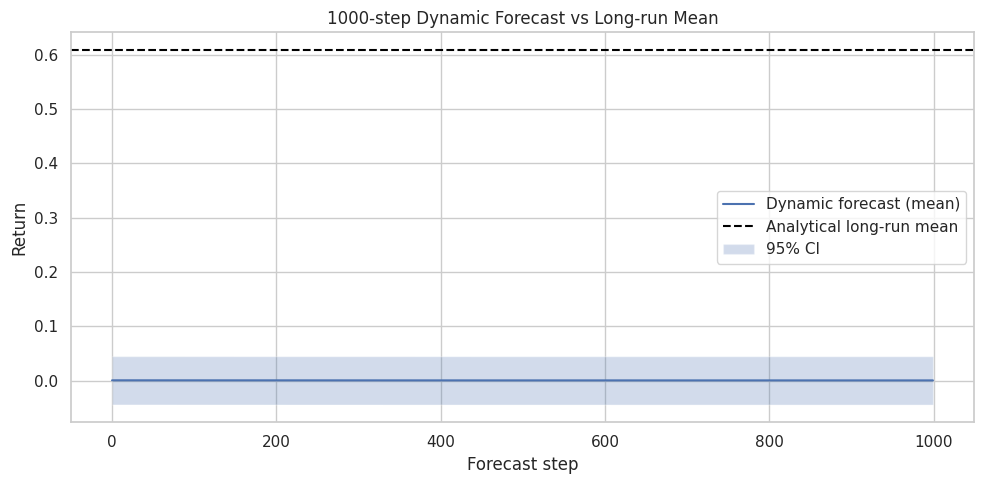

In [22]:
const, phi = best_model.params.get("const", np.nan), best_model.params.get("ar.L1", 0.0)
mu_inf = const / (1 - phi) if abs(phi) < 1 else np.nan
print(f"Analytical long-run mean = {mu_inf:.6f}")

fcst = best_model.get_forecast(steps=1000)
pred_mean, pred_ci = fcst.predicted_mean, fcst.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pred_mean.values, label="Dynamic forecast (mean)")
ax.axhline(mu_inf, linestyle="--", color="black", label="Analytical long-run mean")
ax.fill_between(range(len(pred_mean)), pred_ci.iloc[:, 0], pred_ci.iloc[:, 1], alpha=0.25, label="95% CI")
ax.set(title="1000-step Dynamic Forecast vs Long-run Mean", xlabel="Forecast step", ylabel="Return")
ax.legend(); plt.tight_layout(); plt.savefig("assets/fig6_longrun_forecast.png", dpi=150); plt.show()


### 6e-f. Out-of-sample evaluation vs a white-noise benchmark

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/pyth

ARMA(2, 1) RMSE      = 0.016809
White-noise RMSE          = 0.016809
ARMA beats white noise


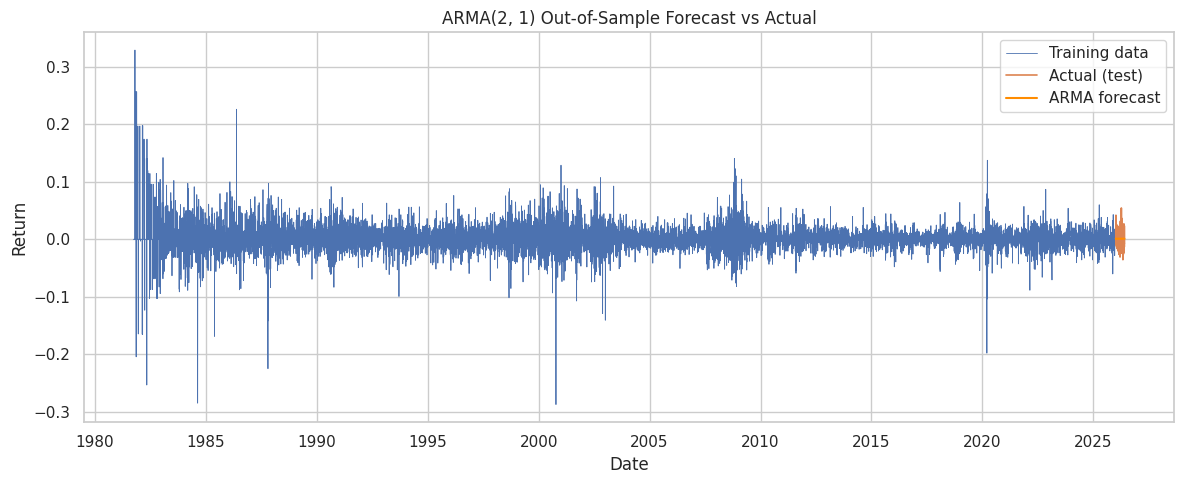

In [23]:
TEST_SIZE = 100
train, test = returns.iloc[:-TEST_SIZE], returns.iloc[-TEST_SIZE:]

arma_oos = ARIMA(train, order=(best_order[0], 0, best_order[1]), trend="c").fit()
fcst_oos = arma_oos.get_forecast(steps=TEST_SIZE)
pred = pd.Series(fcst_oos.predicted_mean.values, index=test.index)

rmse_arma = np.sqrt(mean_squared_error(test, pred))
rmse_white = np.sqrt(mean_squared_error(test, pd.Series(train.mean(), index=test.index)))

print(f"ARMA{best_order} RMSE      = {rmse_arma:.6f}")
print(f"White-noise RMSE          = {rmse_white:.6f}")
print("ARMA beats white noise" if rmse_arma < rmse_white else "ARMA does not beat white noise")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train, linewidth=0.6, label="Training data")
ax.plot(test.index, test, linewidth=1.2, label="Actual (test)")
ax.plot(pred.index, pred, color="darkorange", label="ARMA forecast")
ax.set(title=f"ARMA{best_order} Out-of-Sample Forecast vs Actual", xlabel="Date", ylabel="Return")
ax.legend(); plt.tight_layout(); plt.savefig("assets/fig7_oos_forecast.png", dpi=150); plt.show()


## 7. Extension: formal ARCH test and GARCH(1,1) volatility model

Section 6's residual diagnostics showed persistent autocorrelation in squared
residuals and a BDS test that strongly rejects i.i.d. residuals -- both signs
of conditional heteroskedasticity that an ARMA mean model cannot capture on its
own. This section follows up on that: it formally tests for ARCH effects
(rather than relying on visual inspection of the ACF), fits a GARCH(1,1) on top
of the chosen ARMA mean model, and compares the resulting interval forecasts
with the ARMA-only intervals used in Section 6.

### 7a. Engle's ARCH-LM test

In [24]:
arch_lm_stat, arch_lm_pval, _, _ = het_arch(resid, nlags=10)
print(f"Engle ARCH-LM statistic = {arch_lm_stat:.2f}, p-value = {arch_lm_pval:.4g}")
print("Reject homoskedasticity -> conditional variance should be modelled explicitly."
      if arch_lm_pval < 0.05 else "No strong evidence of ARCH effects at the 5% level.")


Engle ARCH-LM statistic = 674.83, p-value = 1.589e-138
Reject homoskedasticity -> conditional variance should be modelled explicitly.


### 7b. Fit GARCH(1,1) on the ARMA residuals

In [25]:
# pip install arch
from arch import arch_model

resid_pct = resid * 100  # arch_model scales more stably on percentage returns
garch_fit = arch_model(resid_pct, mean="Zero", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(garch_fit.summary())


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -22301.4
Distribution:      Standardized Student's t   AIC:                           44610.8
Method:                  Maximum Likelihood   BIC:                           44640.1
                                              No. Observations:                11201
Date:                      Tue, Jul 07 2026   Df Residuals:                    11201
Time:                              08:33:41   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

### 7c. Conditional volatility and ARMA vs ARMA-GARCH interval forecasts

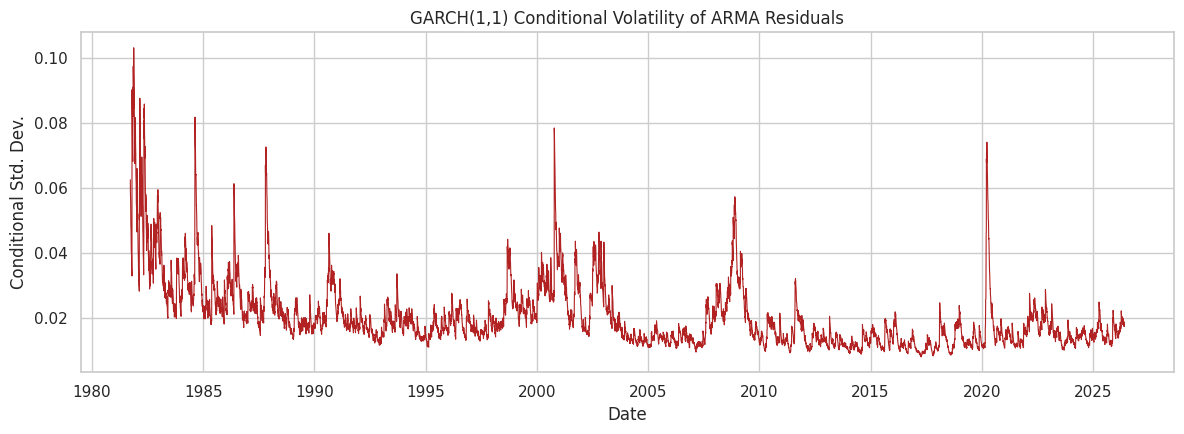

In [26]:
cond_vol = garch_fit.conditional_volatility / 100  # back to return scale

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(resid.index, cond_vol.values, linewidth=0.8, color="firebrick")
ax.set(title="GARCH(1,1) Conditional Volatility of ARMA Residuals",
       xlabel="Date", ylabel="Conditional Std. Dev.")
plt.tight_layout(); plt.savefig("assets/fig8_garch_volatility.png", dpi=150); plt.show()


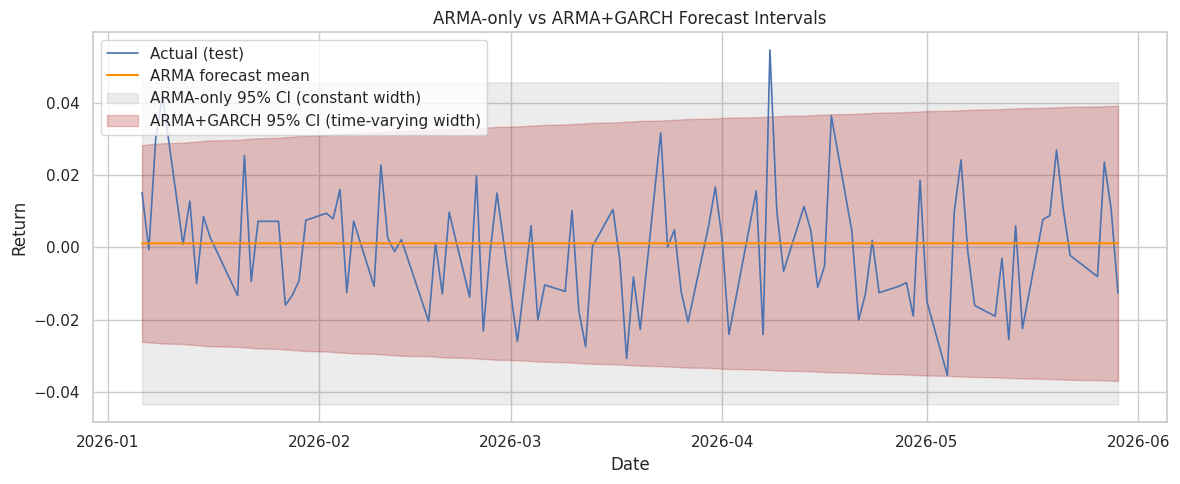

Mean ARMA-only interval half-width   = 0.04453 (constant)
Mean ARMA+GARCH interval half-width  = 0.03333 (time-varying, range 0.02719-0.03805)


In [27]:
# Out-of-sample: compare a constant (ARMA-implied) forecast interval with the
# time-varying GARCH interval over the same TEST_SIZE window used in 6e-f.
garch_oos = arch_model(train.rename("HD_ret") * 100, mean="Zero", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
garch_forecast = garch_oos.forecast(horizon=TEST_SIZE, reindex=False)
garch_sigma = np.sqrt(garch_forecast.variance.values[-1]) / 100  # per-step conditional std dev

arma_sigma_const = np.sqrt(arma_oos.params["sigma2"])  # ARMA's single constant variance

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test.index, test.values, label="Actual (test)", linewidth=1.2)
ax.plot(pred.index, pred.values, color="darkorange", label="ARMA forecast mean")
ax.fill_between(test.index, pred.values - 1.96*arma_sigma_const, pred.values + 1.96*arma_sigma_const,
                alpha=0.15, color="gray", label="ARMA-only 95% CI (constant width)")
ax.fill_between(test.index, pred.values - 1.96*garch_sigma, pred.values + 1.96*garch_sigma,
                alpha=0.25, color="firebrick", label="ARMA+GARCH 95% CI (time-varying width)")
ax.set(title="ARMA-only vs ARMA+GARCH Forecast Intervals", xlabel="Date", ylabel="Return")
ax.legend(); plt.tight_layout(); plt.savefig("assets/fig9_arma_vs_garch_intervals.png", dpi=150); plt.show()

print(f"Mean ARMA-only interval half-width   = {1.96*arma_sigma_const:.5f} (constant)")
print(f"Mean ARMA+GARCH interval half-width  = {(1.96*garch_sigma).mean():.5f} (time-varying, "
      f"range {(1.96*garch_sigma).min():.5f}-{(1.96*garch_sigma).max():.5f})")


### 7d. Interpretation

If the GARCH-based intervals widen around volatile periods and narrow during
calm periods (rather than the constant-width ARMA-only band), that confirms the
conclusion from Sections 6 and 7a: the conditional **mean** of HD's returns is
close to white noise (ARMA barely beats it), but the conditional **variance**
is genuinely time-varying and worth modelling separately for risk-management
purposes such as Value-at-Risk.